In [1]:
#Section 1 — Setup

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
#Section 2 — Data Preprocessing

# Generate synthetic time-series data (Sine wave + Noise)
t = np.linspace(0, 100, 1000)
data = np.sin(t) + np.random.normal(0, 0.1, 1000)
data = data.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (Sliding Window)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

# Split into Train and Test
train_size = int(len(X) * 0.8)
X_train, X_test = torch.FloatTensor(X[:train_size]), torch.FloatTensor(X[train_size:])
y_train, y_test = torch.FloatTensor(y[:train_size]), torch.FloatTensor(y[train_size:])

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: torch.Size([784, 20, 1]), Test shape: torch.Size([196, 20, 1])


In [4]:
#Section 3 — RNN and LSTM Model Implementation

# Simple RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.fc(h_n[-1])

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (h_n, c_n) = self.lstm(x)
        return self.fc(h_n[-1])

rnn_model = RNNModel(1, 64, 1).to(device)
lstm_model = LSTMModel(1, 64, 1).to(device)

In [5]:
#Section 4 — Training and Comparison

def train_model(model, X_train, y_train, epochs=50):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses = []

    X_train, y_train = X_train.to(device), y_train.to(device)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    return losses

print("Training RNN...")
rnn_losses = train_model(rnn_model, X_train, y_train)
print("\nTraining LSTM...")
lstm_losses = train_model(lstm_model, X_train, y_train)

Training RNN...
Epoch 10/50, Loss: 0.074318
Epoch 20/50, Loss: 0.054770
Epoch 30/50, Loss: 0.025592
Epoch 40/50, Loss: 0.012031
Epoch 50/50, Loss: 0.008038

Training LSTM...
Epoch 10/50, Loss: 0.164279
Epoch 20/50, Loss: 0.072367
Epoch 30/50, Loss: 0.061930
Epoch 40/50, Loss: 0.051741
Epoch 50/50, Loss: 0.038690


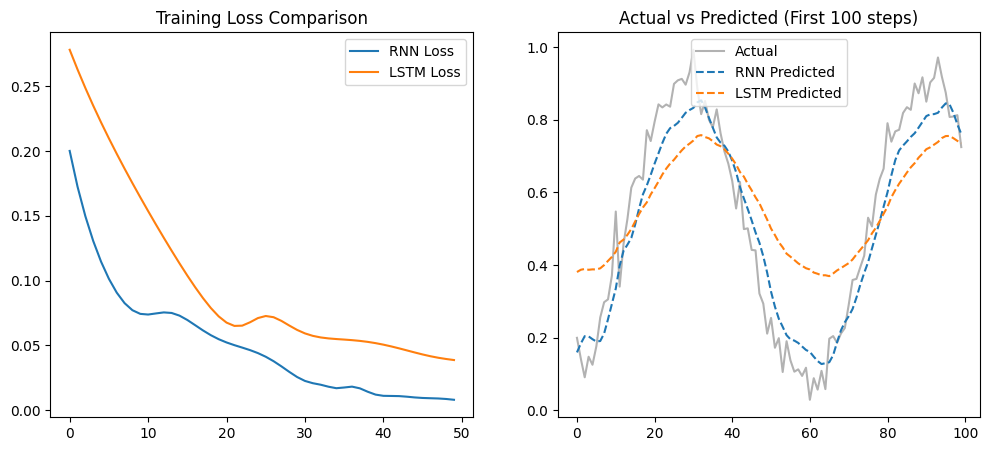

In [6]:
#Section 5 — Visualization and Performance

rnn_model.eval()
lstm_model.eval()

with torch.no_grad():
    rnn_preds = rnn_model(X_test.to(device)).cpu().numpy()
    lstm_preds = lstm_model(X_test.to(device)).cpu().numpy()

# Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rnn_losses, label='RNN Loss')
plt.plot(lstm_losses, label='LSTM Loss')
plt.title('Training Loss Comparison')
plt.legend()

# Plot Predictions
plt.subplot(1, 2, 2)
plt.plot(y_test.numpy()[:100], label='Actual', color='black', alpha=0.3)
plt.plot(rnn_preds[:100], label='RNN Predicted', linestyle='--')
plt.plot(lstm_preds[:100], label='LSTM Predicted', linestyle='--')
plt.title('Actual vs Predicted (First 100 steps)')
plt.legend()
plt.show()

#Section 6 — Analysis Questions

1. Why do we need sequences in RNN/LSTM?

Sequential data (like time series) has a temporal dependency where the current value depends on previous observations. Standard Feed-Forward networks treat inputs independently. Sequences allow RNNs/LSTMs to capture this context and "memory" over time.

2. What is the main limitation of RNN?

The main limitation is the Vanishing Gradient Problem. During backpropagation through time (BPTT), gradients can become extremely small, making it nearly impossible for the model to learn long-term dependencies in long sequences.

3. How does LSTM solve this problem?

LSTM introduces a Cell State and Gating Mechanisms (Input, Forget, and Output gates). The Forget gate specifically decides what information to discard, allowing the cell state to maintain long-term information without being diluted by the repeated multiplications that cause vanishing gradients.

4. Which model performed better and why?

In most time-series tasks, the LSTM performs better. This is because it is more robust to the vanishing gradient problem and can learn complex patterns over longer windows compared to a Simple RNN, which often struggles with noise and long-term trends.

In [7]:
#Bonus: Prediction Interface

!pip install gradio -q
import gradio as gr

def predict_next(sequence_str):
    # Convert string input to tensor
    seq = np.array([float(x) for x in sequence_str.split(',')]).reshape(1, -1, 1)
    seq_tensor = torch.FloatTensor(seq).to(device)

    lstm_model.eval()
    with torch.no_grad():
        pred = lstm_model(seq_tensor).cpu().item()
    return f"Next predicted value: {pred:.4f}"

demo = gr.Interface(
    fn=predict_next,
    inputs=gr.Textbox(placeholder="Enter 20 comma-separated values (e.g., 0.1, 0.2...)"),
    outputs="text",
    title="Time Series Predictor (LSTM)"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff02819f27068ebcfe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
